# **21장. 강화학습과 Q-러닝**

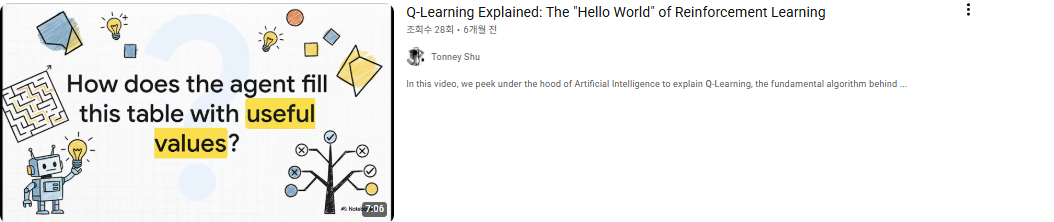

https://www.youtube.com/watch?v=XkCD7mrBoII

이 동영상은 Q-테이블을 활용한 강화학습의 원리를 쉽게 설명해줍니다.
* 영상 중 벨만 방정식에서 학습율인 alpha가 1이 되면 책의 설명과 같아집니다.  


---



**Grid World 환경**

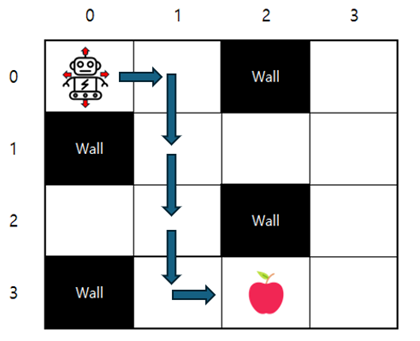

[실습 21-01]

In [ ]:
## 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# 환경 설정
그리드_수=[4, 4]
목표_셀=(3, 2)
차단_셀=[(2, 2), (3,0), (1,0), (0,2)]
출발_셀=(0, 0)

행동_이름=['up', 'down', 'left', 'right']
n_actions=4  # 행동의 수

[실습 21-02]

In [ ]:
# 다음 상태 계산 함수
def state_move(state, action):  # 현재 상태와 행동을 입력받음
    x, y = state
    if action == 0:    # up
        next = (max(x - 1, 0), y)
    elif action == 1:  # down
        next = (min(x + 1, 3), y)
    elif action == 2:  # left
        next = (x, max(y - 1, 0))
    elif action == 3:  # right
        next = (x, min(y + 1, 3))

    # 차단_셀에 부딪히면 움직이지 않음
    if next in 차단_셀: # in 은 포함되면 이란 뜻
        next = state
    return next


[실습 21-03]

In [ ]:
print(state_move((2, 2), 2))     # left 정상 이동
print(state_move((2, 2), 0))     # up 정상 이동
print(state_move((3, 2), 1))     # down -> 아래쪽으로 탈출 시도
print(state_move((1, 2), 1))     # 벽에 부딪힘
print(state_move((1, 3), 3))     # right -> 오른쪽으로 탈출 시도


(2, 1)
(1, 2)
(3, 2)
(1, 2)
(1, 3)


[실습 21-04]

In [ ]:
def reward(state):
    return 1 if state == 목표_셀 else -0.1

print(reward((2, 2)))
print(reward((3, 2)))

-0.1
1


[실습 21-05]

In [ ]:
상태=출발_셀
총_보상=0
for step in range(10):
    행동=random.randint(0, 3)		# 무작위 행동 선택

    다음_상태=state_move(상태, 행동)	# 다음 상태 결정
    보상=reward(다음_상태)
    총_보상 += 보상
    상태=다음_상태				        # 상태 업데이트
    print(
        f"스텝={step+1:2} | "
        f"행동={행동:2}  |"
        f"다음 상태={str(상태)} |"
        f" 보상={ 보상:.1f} | "
        f"총_보상={총_보상:.2f} | "
    )

스텝= 1 | 행동= 1  |다음 상태=(0, 0) | 보상=-0.1 | 총_보상=-0.10 | 
스텝= 2 | 행동= 2  |다음 상태=(0, 0) | 보상=-0.1 | 총_보상=-0.20 | 
스텝= 3 | 행동= 1  |다음 상태=(0, 0) | 보상=-0.1 | 총_보상=-0.30 | 
스텝= 4 | 행동= 0  |다음 상태=(0, 0) | 보상=-0.1 | 총_보상=-0.40 | 
스텝= 5 | 행동= 0  |다음 상태=(0, 0) | 보상=-0.1 | 총_보상=-0.50 | 
스텝= 6 | 행동= 3  |다음 상태=(0, 1) | 보상=-0.1 | 총_보상=-0.60 | 
스텝= 7 | 행동= 0  |다음 상태=(0, 1) | 보상=-0.1 | 총_보상=-0.70 | 
스텝= 8 | 행동= 1  |다음 상태=(1, 1) | 보상=-0.1 | 총_보상=-0.80 | 
스텝= 9 | 행동= 1  |다음 상태=(2, 1) | 보상=-0.1 | 총_보상=-0.90 | 
스텝=10 | 행동= 3  |다음 상태=(2, 1) | 보상=-0.1 | 총_보상=-1.00 | 


[실습 21-06]

In [ ]:
np.set_printoptions(precision=3, suppress=True)  # 소숫점 조절

# 랜덤 시드 고정
np.random.seed(42); random.seed(42)

# Q-테이블 랜덤 초기화
Q=np.random.rand(4, 4, 4)    # 3차원 배열

print("학습 이전의 Q-테이블")
print(Q); print()

상태=(3,1)
print(f"{상태}에서 행동별 Q값 = {Q[상태[0],상태[1],:]}")
print(f"{상태}에서 최적 행동 = {np.argmax(Q[상태[0],상태[1],:])}")

a=np.argmax(Q[상태[0],상태[1],:])  # Q가 가장 큰 행동 선택
다음_상태=state_move(상태, a)

print(f"{상태}에서 행동 [{a}]를 할 경우의 다음 상태 = { 다음_상태}")
print(f"{상태}에서 행동 [{a}]의 보상 = ", reward(다음_상태))

학습 이전의 Q-테이블
[[[0.375 0.951 0.732 0.599]
  [0.156 0.156 0.058 0.866]
  [0.601 0.708 0.021 0.97 ]
  [0.832 0.212 0.182 0.183]]

 [[0.304 0.525 0.432 0.291]
  [0.612 0.139 0.292 0.366]
  [0.456 0.785 0.2   0.514]
  [0.592 0.046 0.608 0.171]]

 [[0.065 0.949 0.966 0.808]
  [0.305 0.098 0.684 0.44 ]
  [0.122 0.495 0.034 0.909]
  [0.259 0.663 0.312 0.52 ]]

 [[0.547 0.185 0.97  0.775]
  [0.939 0.895 0.598 0.922]
  [0.088 0.196 0.045 0.325]
  [0.389 0.271 0.829 0.357]]]

(3, 1)에서 행동별 Q값 = [0.939 0.895 0.598 0.922]
(3, 1)에서 최적 행동 = 0
(3, 1)에서 행동 [0]를 할 경우의 다음 상태 = (2, 1)
(3, 1)에서 행동 [0]의 보상 =  -0.1


[실습 21-07]

In [ ]:
# 하이퍼 파라미터 설정
n_episodes=10   # 에피소드 수

# 랜덤 시드 고정
np.random.seed(42); random.seed(42)

# 학습 루프
for ep in range(n_episodes):
    상태=출발_셀
    총_보상=0
    종료=False
    step=0

    while 종료==False:
        행동=np.argmax(Q[상태[0], 상태[1], :])  # Q값을 사용한 최적 행동

        다음_상태=state_move(상태, 행동)
        보상=reward(다음_상태)
        총_보상 += 보상
        종료=(다음_상태 == 목표_셀)         # 다음_상태가 목표_셀이면 종료

        # 선택된 행동의 Q값 업데이트
        Q[상태[0], 상태[1], 행동]= 보상

        if step>=50: # 50 스텝 이상이면 강제 종료
          break

        상태=다음_상태
        step += 1    # 다음 스텝으로 진행

    print(
        f"에피소드={ep+1:2} | "
        f"목표 도달 스텝 수={step:2}  |"
        f"총_보상={총_보상:.2f} | " )

print()
print("학습 완료된 Q-테이블")
print(Q)

에피소드= 1 | 목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드= 2 | 목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드= 3 | 목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드= 4 | 목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드= 5 | 목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드= 6 | 목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드= 7 | 목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드= 8 | 목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드= 9 | 목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=10 | 목표 도달 스텝 수=50  |총_보상=-5.10 | 

학습 완료된 Q-테이블
[[[-0.1   -0.1   -0.1   -0.1  ]
  [-0.1   -0.1   -0.1   -0.1  ]
  [ 0.601  0.708  0.021  0.97 ]
  [ 0.832  0.212  0.182  0.183]]

 [[ 0.304  0.525  0.432  0.291]
  [-0.1    0.139  0.292  0.366]
  [ 0.456  0.785  0.2    0.514]
  [ 0.592  0.046  0.608  0.171]]

 [[ 0.065  0.949  0.966  0.808]
  [ 0.305  0.098  0.684  0.44 ]
  [ 0.122  0.495  0.034  0.909]
  [ 0.259  0.663  0.312  0.52 ]]

 [[ 0.547  0.185  0.97   0.775]
  [ 0.939  0.895  0.598  0.922]
  [ 0.088  0.196  0.045  0.325]
  [ 0.389  0.271  0.829  0.357]]]


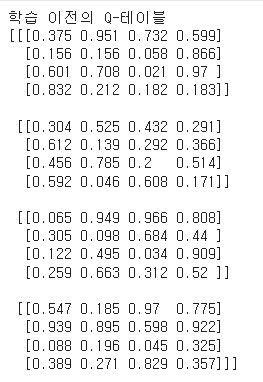

[실습 21-08]

In [ ]:
# 하이퍼 파라미터 설정
gamma=0.9       # 할인율
n_episodes=500  # 에피소드 수

e=1		          # 초기 탐험 비율
e_decay=0.99	  # 탐험 비율 감소율

# 랜덤 시드 고정
np.random.seed(42); random.seed(42)

# Q-테이블 랜덤 초기화
Q=np.random.rand(4, 4, 4)

# 학습 루프
for ep in range(n_episodes):
    상태=출발_셀
    총_보상=0
    종료=False
    step=0

    while 종료==False:

        if random.uniform(0, 1) < e:
            행동=random.randint(0, 3)               # 탐험
        else:
            행동=np.argmax(Q[상태[0], 상태[1], :])  # 활용

        다음_상태=state_move(상태, 행동)
        보상=reward(다음_상태)
        총_보상 += 보상
        종료=(다음_상태 == 목표_셀)


        # Q값 업데이트
        Q[상태[0], 상태[1], 행동]=보상

        # 강제 종료
        if step>=50:
          break

        상태=다음_상태
        step += 1

    e=e*e_decay  # 탐험 비율 감소
    print(
        f"에피소드={ep+1:4} | "
        f"탐험비율={e:.5f}  |"
        f"목표 도달 스텝 수={step:2}  |"
        f"총_보상={총_보상:.2f} | " )

print()
print("학습 완료된 Q-테이블")
print(Q)

에피소드=   1 | 탐험비율=0.99000  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=   2 | 탐험비율=0.98010  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=   3 | 탐험비율=0.97030  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=   4 | 탐험비율=0.96060  |목표 도달 스텝 수=23  |총_보상=-1.20 | 
에피소드=   5 | 탐험비율=0.95099  |목표 도달 스텝 수=35  |총_보상=-2.40 | 
에피소드=   6 | 탐험비율=0.94148  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=   7 | 탐험비율=0.93207  |목표 도달 스텝 수=48  |총_보상=-3.70 | 
에피소드=   8 | 탐험비율=0.92274  |목표 도달 스텝 수=41  |총_보상=-3.00 | 
에피소드=   9 | 탐험비율=0.91352  |목표 도달 스텝 수=13  |총_보상=-0.20 | 
에피소드=  10 | 탐험비율=0.90438  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=  11 | 탐험비율=0.89534  |목표 도달 스텝 수=40  |총_보상=-2.90 | 
에피소드=  12 | 탐험비율=0.88638  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=  13 | 탐험비율=0.87752  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=  14 | 탐험비율=0.86875  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=  15 | 탐험비율=0.86006  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=  16 | 탐험비율=0.85146  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=  17 | 탐험비율=0.84294  |목표 도달 스텝 수=50  |총_보상=-5.10 | 
에피소드=  18 | 탐험비율=0.83451  |목표 도

[실습 21-09]

In [ ]:
# 하이퍼 파라미터 설정
gamma=0.9       # 할인율
n_episodes=500  # 에피소드 수

e=1		  # 초기 탐험 비율
e_decay=0.99	  # 탐험 비율 감소율

# 랜덤 시드 고정
np.random.seed(42); random.seed(42)

# Q-테이블 랜덤 초기화
Q=np.random.rand(4, 4, 4)

# 학습 루프
for ep in range(n_episodes):
    상태=출발_셀
    총_보상=0
    종료=False
    step=0

    while 종료==False:

        if random.uniform(0, 1) < e:
            행동=random.randint(0, 3)               # 탐험
        else:
            행동=np.argmax(Q[상태[0], 상태[1], :])  # 활용

        다음_상태=state_move(상태, 행동)
        보상=reward(다음_상태)
        총_보상 += 보상
        종료=(다음_상태 == 목표_셀)


        # 선택된 행동의 Q값 업데이트
        Q[상태[0], 상태[1], 행동]=보상 + gamma*np.max(Q[다음_상태[0], 다음_상태[1], :])*(종료==False)

        상태=다음_상태
        step += 1

    e=e*e_decay  # 탐험 비율 감소
    print(
        f"에피소드={ep+1:4} | "
        f"탐험비율={e:.5f}  |"
        f"목표 도달 스텝 수={step:2}  |"
        f"총_보상={총_보상:.2f} | " )

print()
print("학습 완료된 Q-테이블")
print(Q)

에피소드=   1 | 탐험비율=0.99000  |목표 도달 스텝 수=78  |총_보상=-6.70 | 
에피소드=   2 | 탐험비율=0.98010  |목표 도달 스텝 수=97  |총_보상=-8.60 | 
에피소드=   3 | 탐험비율=0.97030  |목표 도달 스텝 수=35  |총_보상=-2.40 | 
에피소드=   4 | 탐험비율=0.96060  |목표 도달 스텝 수=95  |총_보상=-8.40 | 
에피소드=   5 | 탐험비율=0.95099  |목표 도달 스텝 수=49  |총_보상=-3.80 | 
에피소드=   6 | 탐험비율=0.94148  |목표 도달 스텝 수=19  |총_보상=-0.80 | 
에피소드=   7 | 탐험비율=0.93207  |목표 도달 스텝 수=29  |총_보상=-1.80 | 
에피소드=   8 | 탐험비율=0.92274  |목표 도달 스텝 수=26  |총_보상=-1.50 | 
에피소드=   9 | 탐험비율=0.91352  |목표 도달 스텝 수=23  |총_보상=-1.20 | 
에피소드=  10 | 탐험비율=0.90438  |목표 도달 스텝 수=32  |총_보상=-2.10 | 
에피소드=  11 | 탐험비율=0.89534  |목표 도달 스텝 수=30  |총_보상=-1.90 | 
에피소드=  12 | 탐험비율=0.88638  |목표 도달 스텝 수=91  |총_보상=-8.00 | 
에피소드=  13 | 탐험비율=0.87752  |목표 도달 스텝 수=47  |총_보상=-3.60 | 
에피소드=  14 | 탐험비율=0.86875  |목표 도달 스텝 수=12  |총_보상=-0.10 | 
에피소드=  15 | 탐험비율=0.86006  |목표 도달 스텝 수=19  |총_보상=-0.80 | 
에피소드=  16 | 탐험비율=0.85146  |목표 도달 스텝 수=11  |총_보상=0.00 | 
에피소드=  17 | 탐험비율=0.84294  |목표 도달 스텝 수=10  |총_보상=0.10 | 
에피소드=  18 | 탐험비율=0.83451  |목표 도달 

[실습 21-10]

In [ ]:
print("최적 경로")
상태=출발_셀
종료=False
while 종료==False:
        행동=np.argmax(Q[상태[0], 상태[1], ])
        다음_상태=state_move(상태, 행동)
        종료=(다음_상태==목표_셀)
        상태=다음_상태
        print(상태, end="-> ")
print("목표 도달")

최적 경로
(0, 1)-> (1, 1)-> (2, 1)-> (3, 1)-> (3, 2)-> 목표 도달
